# Imports

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
from sqlite3 import connect

In [2]:
csv = pd.read_csv("./data/daily_activity.csv")
csv['ActivityDate'] = pd.to_datetime(csv['ActivityDate'])
csv

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-03-25,11004,7.110000,7.110000,0.0,2.57,0.46,4.07,0.00,33,12,205,804,1819
1,1503960366,2016-03-26,17609,11.550000,11.550000,0.0,6.92,0.73,3.91,0.00,89,17,274,588,2154
2,1503960366,2016-03-27,12736,8.530000,8.530000,0.0,4.66,0.16,3.71,0.00,56,5,268,605,1944
3,1503960366,2016-03-28,13231,8.930000,8.930000,0.0,3.19,0.79,4.95,0.00,39,20,224,1080,1932
4,1503960366,2016-03-29,12041,7.850000,7.850000,0.0,2.16,1.09,4.61,0.00,28,28,243,763,1886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,8877689391,2016-04-08,23014,20.389999,20.389999,0.0,11.10,0.63,8.62,0.00,70,29,359,982,4196
453,8877689391,2016-04-09,16470,8.070000,8.070000,0.0,0.00,0.02,8.02,0.00,90,9,289,1052,3841
454,8877689391,2016-04-10,28497,27.530001,27.530001,0.0,21.92,1.12,4.46,0.00,128,46,211,1055,4526
455,8877689391,2016-04-11,10622,8.060000,8.060000,0.0,1.47,0.15,6.37,0.01,18,7,225,1190,2820


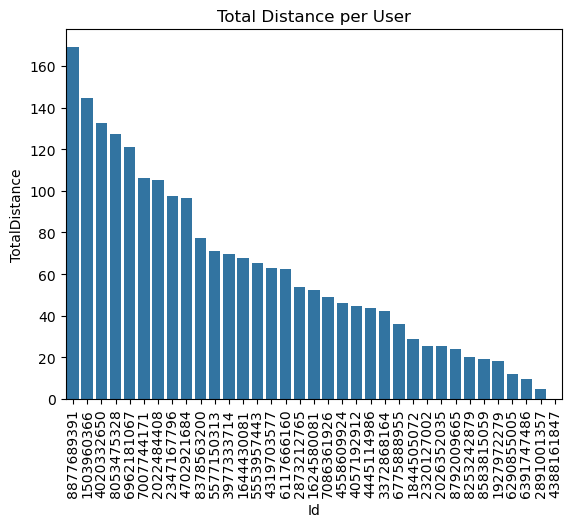

In [3]:
total_dist = csv.groupby('Id')['TotalDistance'].sum().sort_values(ascending=False)
sns.barplot(total_dist, order=total_dist.index)
plt.title("Total Distance per User")
plt.xticks(rotation=90)
plt.show()

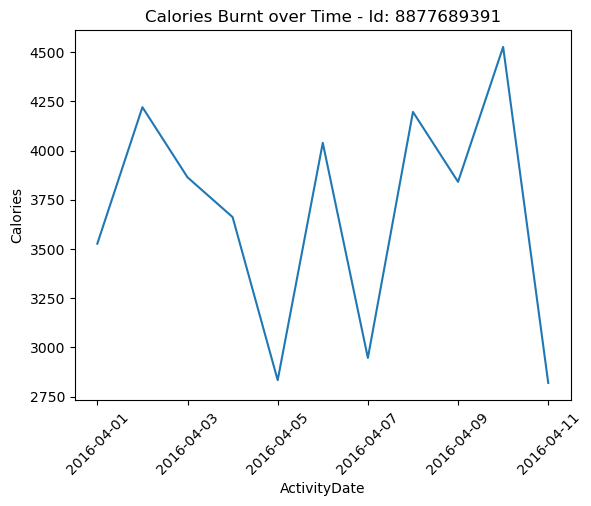

In [4]:
def plot_calories_burnt(id, startdate, enddate):
    ts = (
        csv[csv['Id'] == id]
        .set_index('ActivityDate')['Calories']
        .loc[pd.to_datetime(startdate):pd.to_datetime(enddate)]
    )
    sns.lineplot(ts)
    plt.title(f"Calories Burnt over Time - Id: {id}")
    plt.xticks(rotation=45)
    plt.show()

plot_calories_burnt(8877689391, '4/1/2016', '4/11/2016')

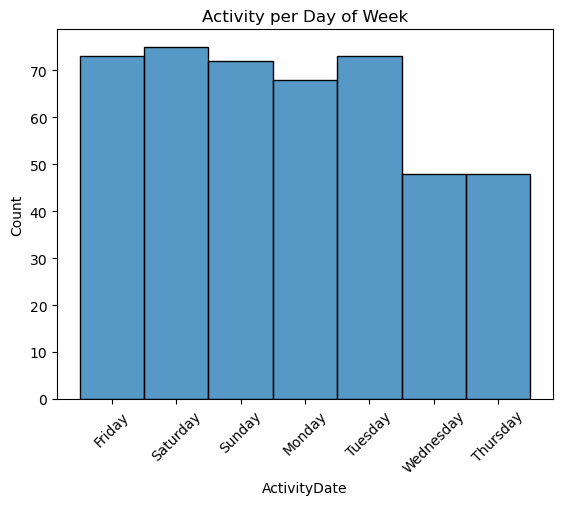

In [5]:
dow = csv['ActivityDate'].dt.day_name()
sns.histplot(dow, bins=7)
plt.title("Activity per Day of Week")
plt.xticks(rotation=45)
plt.show()

In [6]:
def plot_linear_regression(X, y, title="Title"):
    model = sm.OLS(y, X)
    results = model.fit()
    beta = results.params.values
    y_pred = X.dot(beta)
    
    sns.scatterplot(y, label='Data')
    sns.lineplot(y_pred, label='Regression')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

    errors = y - y_pred
    sns.histplot(errors)
    plt.title("Regression Errors")
    plt.show()

    print(results.summary())

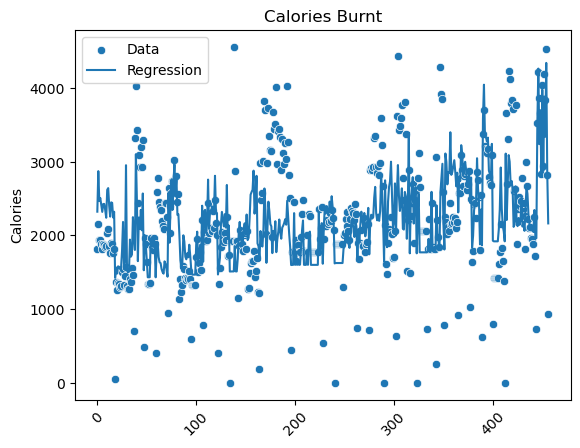

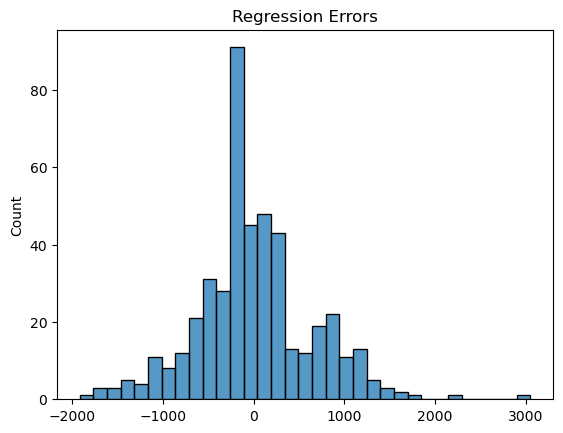

                            OLS Regression Results                            
Dep. Variable:               Calories   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.380
Method:                 Least Squares   F-statistic:                     141.0
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           2.41e-48
Time:                        20:44:49   Log-Likelihood:                -3601.2
No. Observations:                 457   AIC:                             7208.
Df Residuals:                     454   BIC:                             7221.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1291.1515     73.370     17.598      0.0

In [7]:
y = csv['Calories']
X = csv[['TotalSteps', 'Id']]
X = sm.add_constant(X)

plot_linear_regression(X, y, title="Calories Burnt")

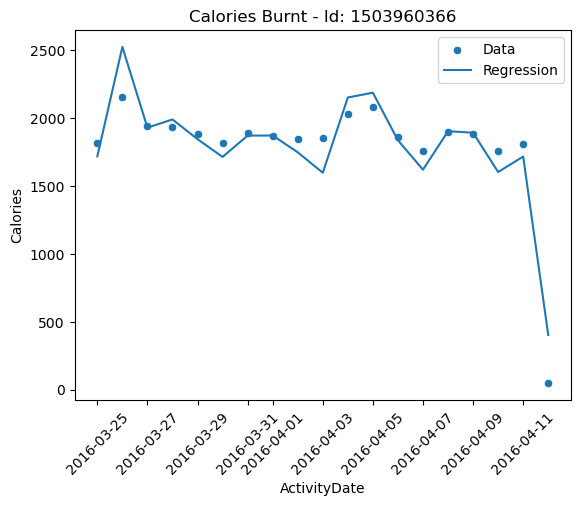

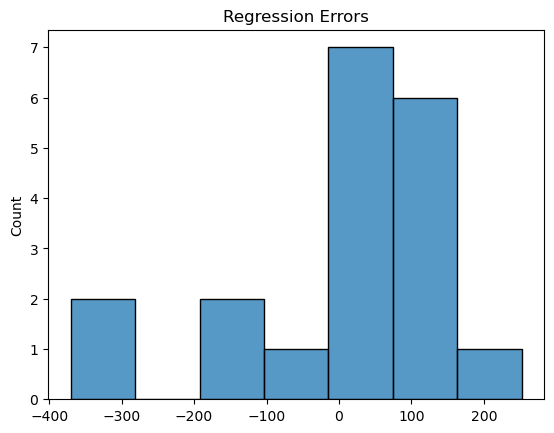

                            OLS Regression Results                            
Dep. Variable:               Calories   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     115.3
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           5.41e-09
Time:                        20:44:49   Log-Likelihood:                -122.39
No. Observations:                  19   AIC:                             248.8
Df Residuals:                      17   BIC:                             250.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        376.2041    137.289      2.740      0.0

In [8]:
def plot_calories(id):
    data = csv[csv['Id'] == id].set_index('ActivityDate')
    y = data['Calories']
    X = data[['TotalSteps']]
    X = sm.add_constant(X)
    plot_linear_regression(X, y, f"Calories Burnt - Id: {id}")

plot_calories(csv['Id'][0])